In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files

sns.set_theme()

Load the Week 1 cleaned dataset

In [9]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

Q1 = df["TotalSales"].quantile(0.25)
Q3 = df["TotalSales"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df["TotalSales_Capped"] = df["TotalSales"].clip(lower, upper)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (524878, 10)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,TotalSales_Capped
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34


Basic inspection and descriptive statistics

In [10]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
display(df[["Quantity", "UnitPrice", "TotalSales"]].describe())

print("\n===== UNIQUE VALUES =====")
print("Customers:", df["CustomerID"].nunique())
print("Countries:", df["Country"].nunique())
print("Products:", df["StockCode"].nunique())
print("Invoices:", df["InvoiceNo"].nunique())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   InvoiceNo          524878 non-null  object        
 1   StockCode          524878 non-null  object        
 2   Description        524878 non-null  object        
 3   Quantity           524878 non-null  int64         
 4   InvoiceDate        524878 non-null  datetime64[ns]
 5   UnitPrice          524878 non-null  float64       
 6   CustomerID         392692 non-null  float64       
 7   Country            524878 non-null  object        
 8   TotalSales         524878 non-null  float64       
 9   TotalSales_Capped  524878 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 44.0+ MB

===== DESCRIPTIVE STATISTICS =====


,Quantity,UnitPrice,TotalSales
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000



===== UNIQUE VALUES =====
Customers: 4338
Countries: 38
Products: 3922
Invoices: 19960


Overall sales and quantity analysis

Total Sales: £10,642,110.80
Total Quantity Sold: 5,572,420
Average Transaction Value: £20.28


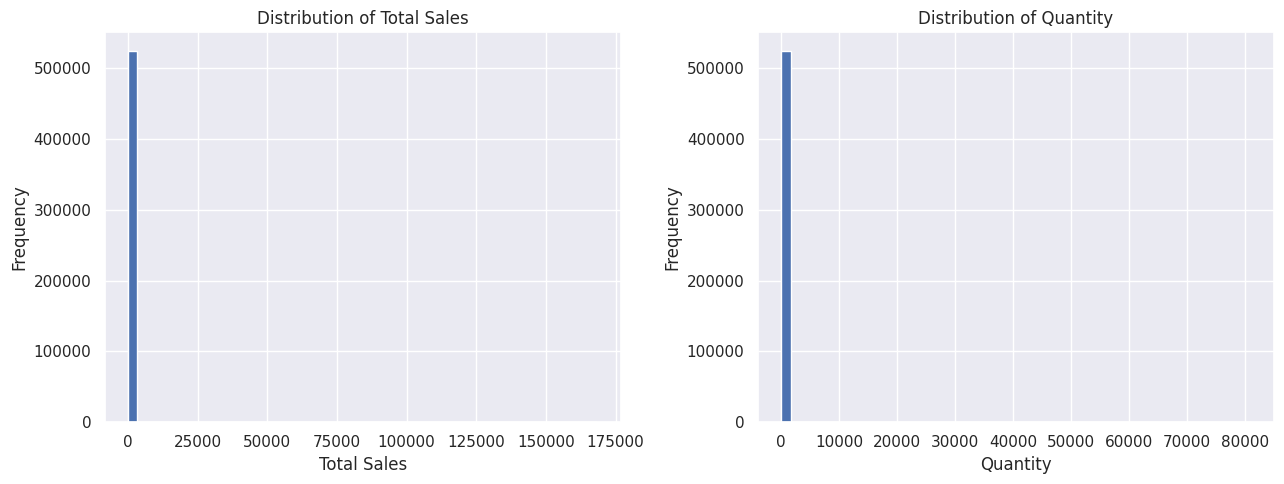

In [11]:
total_sales = df["TotalSales"].sum()
total_quantity = df["Quantity"].sum()
avg_transaction = df["TotalSales"].mean()

print(f"Total Sales: £{total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Transaction Value: £{avg_transaction:,.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(df["TotalSales"], bins=50)
ax[0].set_title("Distribution of Total Sales")
ax[0].set_xlabel("Total Sales")
ax[0].set_ylabel("Frequency")

ax[1].hist(df["Quantity"], bins=50)
ax[1].set_title("Distribution of Quantity")
ax[1].set_xlabel("Quantity")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

sales by country

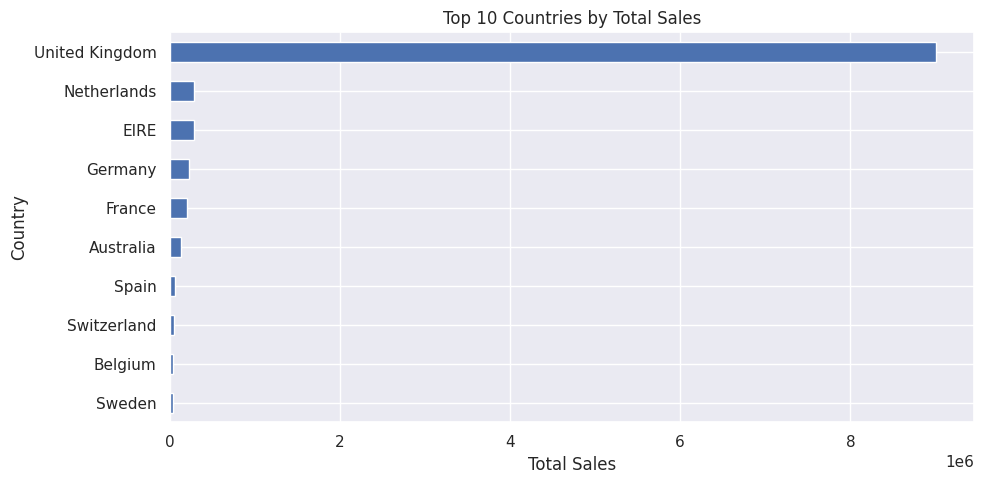

,Total Sales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [12]:
country_sales = df.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
country_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(country_sales.to_frame("Total Sales"))

Top-selling products

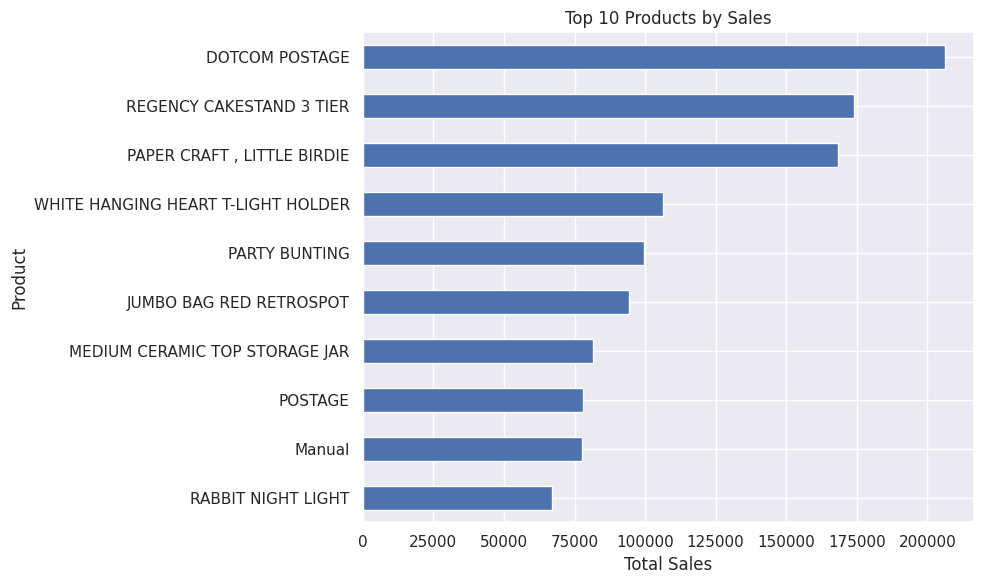

,Total Sales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


In [13]:
product_sales = df.groupby("Description")["TotalSales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
product_sales.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

display(product_sales.to_frame("Total Sales"))

Monthly sales trend

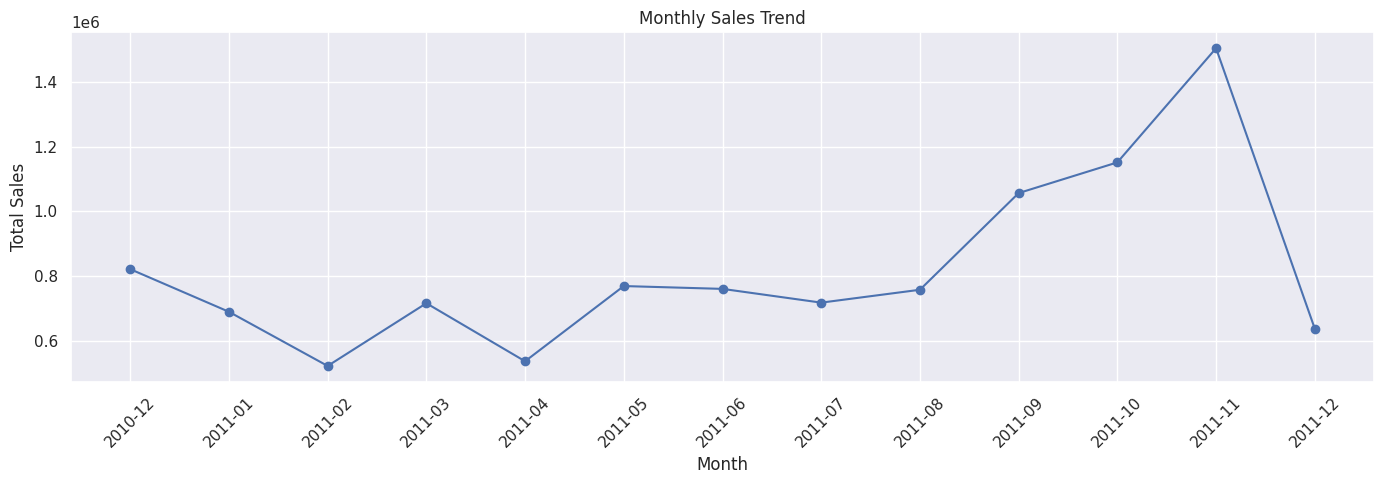

,Total Sales
YearMonth,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [14]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("YearMonth")["TotalSales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

display(monthly_sales.to_frame("Total Sales"))

Boxplots for detecting outliers

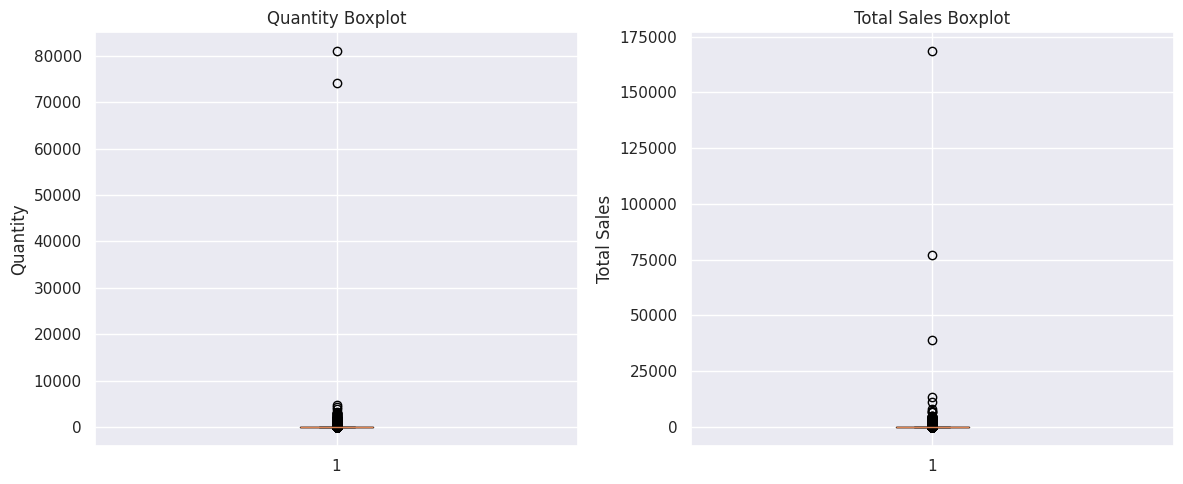

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].boxplot(df["Quantity"])
ax[0].set_title("Quantity Boxplot")
ax[0].set_ylabel("Quantity")

ax[1].boxplot(df["TotalSales"])
ax[1].set_title("Total Sales Boxplot")
ax[1].set_ylabel("Total Sales")

plt.tight_layout()
plt.show()

Relationship between Quantity and Sales

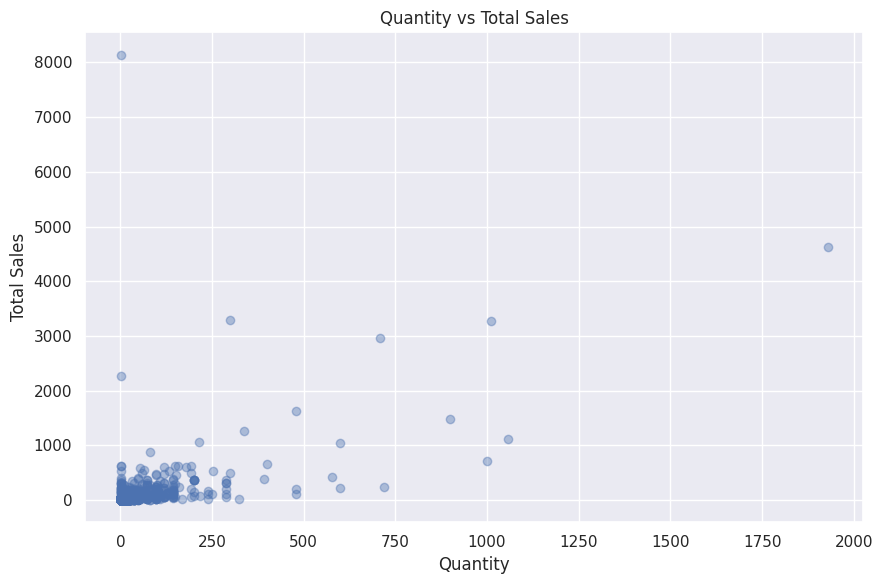

In [16]:
sample_df = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(sample_df["Quantity"], sample_df["TotalSales"], alpha=0.4)
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

Correlation heatmap

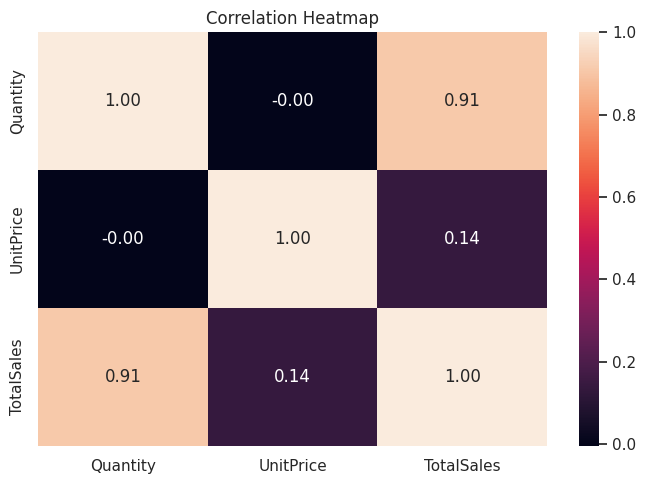

In [17]:
corr = df[["Quantity", "UnitPrice", "TotalSales"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Customer sales analysis

In [18]:
customer_sales = df.groupby("CustomerID").agg(
    TotalSales=("TotalSales", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfOrders=("InvoiceNo", "nunique")
).sort_values("TotalSales", ascending=False)

display(customer_sales.head(10))

print("Total identifiable customers:", len(customer_sales))

,TotalSales,TotalQuantity,NumberOfOrders
CustomerID,,,
14646.0,280206.02,196915,73
18102.0,259657.30,64124,60
17450.0,194390.79,69973,46
16446.0,168472.50,80997,2
14911.0,143711.17,80240,201
12415.0,124914.53,77374,21
14156.0,117210.08,57768,55
17511.0,91062.38,64549,31
16029.0,80850.84,40108,63


Total identifiable customers: 4338


Key EDA findings

In [19]:
print("========== KEY EDA FINDINGS ==========")

print(f"Highest sales country: {country_sales.index[0]}")
print(f"Highest country sales: £{country_sales.iloc[0]:,.2f}")

print(f"\nTop-selling product: {product_sales.index[0]}")
print(f"Top product sales: £{product_sales.iloc[0]:,.2f}")

print(f"\nHighest sales month: {monthly_sales.idxmax()}")
print(f"Highest monthly sales: £{monthly_sales.max():,.2f}")

print(f"\nLowest sales month: {monthly_sales.idxmin()}")
print(f"Lowest monthly sales: £{monthly_sales.min():,.2f}")

print(f"\nTotal sales: £{total_sales:,.2f}")
print(f"Average transaction value: £{avg_transaction:,.2f}")

========== KEY EDA FINDINGS ==========
Highest sales country: United Kingdom
Highest country sales: £9,001,744.09

Top-selling product: DOTCOM POSTAGE
Top product sales: £206,248.77

Highest sales month: 2011-11
Highest monthly sales: £1,503,866.78

Lowest sales month: 2011-02
Lowest monthly sales: £522,545.56

Total sales: £10,642,110.80
Average transaction value: £20.28


Save visualizations

In [20]:
os.makedirs("week2_output", exist_ok=True)

country_sales.to_csv("week2_output/country_sales.csv")
product_sales.to_csv("week2_output/product_sales.csv")
monthly_sales.to_csv("week2_output/monthly_sales.csv")
customer_sales.to_csv("week2_output/customer_sales.csv")

print("Week 2 analysis files saved successfully.")

Week 2 analysis files saved successfully.
